In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA


In [ ]:
def clean_data(file):
    df = pd.read_csv(file)

    Y = df['ClaimNb']

    df['VehIsregular'] = (df['VehGas'] == 'Regular').astype(int)

    df = df.drop(columns= ['VehGas', 'IDpol', 'ClaimNb'])

    def letter_to_index(letter):
        return ord(letter.upper()) - ord('A')

    df['Area'] = df['Area'].apply(letter_to_index)

    df = pd.get_dummies(df)

    scaler = StandardScaler()
    X = scaler.fit_transform(df)
   
    return X, Y

def split_data(X, Y, test_size):
    return train_test_split(X, Y, test_size=test_size, random_state=1)


In [ ]:
X, Y = clean_data("claims_train.csv")

X_train, X_val, y_train, y_val = split_data(X, Y, 0.2)

In [ ]:
def tune_models(X_train, X_val, y_train, y_val):
    
    results = {} 
    
    cv = KFold(n_splits=3, shuffle=True, random_state=1)

    dt_regressor = DecisionTreeRegressor(random_state=1)
    dt_params = {'ccp_alpha': [0.0, 0.00001, 0.0001, 0.001, 0.01]}
    
    dt = GridSearchCV(
        dt_regressor, 
        param_grid=dt_params, 
        cv=cv, 
        scoring='neg_mean_squared_error', 
        n_jobs=-1 
    )
    dt.fit(X_train, y_train)

    dt_best = dt.best_estimator_
    eval_results = evaluate_model(dt_best, X_val, y_val)
    
    results['DecisionTree'] = {
        'evaluation': eval_results,
        'best_params': dt.best_params_
    }

def evaluate_model(model, X_val, y_val):
    """Evaluate a regression model on validation data."""
    y_pred = model.predict(X_val)
    
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    
    return {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }


In [93]:

# Keep ALL components (baseline)
pca_all = PCA()
X_all = pca_all.fit_transform(X)
print("All components:", X_all.shape)
print("Variance explained (should be 1.0):", np.round(pca_all.explained_variance_ratio_.sum(), 3))

# Keep enough for 95% variance
pca95 = PCA(n_components=0.95)
X_95 = pca95.fit_transform(X)
print("\n95% variance:")
print("Shape:", X_95.shape)
print("Variance explained:", np.round(pca95.explained_variance_ratio_.sum(), 3))

# Keep a fixed number (e.g., 10 PCs)
pca10 = PCA(n_components=10)
X_10 = pca10.fit_transform(X)
print("\n10 components:")
print("Shape:", X_10.shape)
print("Variance explained:", np.round(pca10.explained_variance_ratio_.sum(), 3))



All components: (542410, 41)
Variance explained (should be 1.0): 1.0

95% variance:
Shape: (542410, 35)
Variance explained: 0.954

10 components:
Shape: (542410, 10)
Variance explained: 0.351


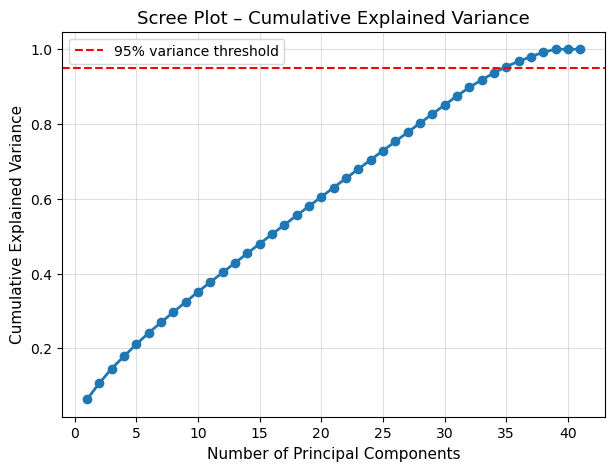

In [94]:
cum_var = np.cumsum(pca_all.explained_variance_ratio_)

plt.figure(figsize=(7,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', linewidth=2, markersize=6)
plt.axhline(y=0.95, color='red', linestyle='--', label='95% variance threshold')
plt.title("Scree Plot – Cumulative Explained Variance", fontsize=13)
plt.xlabel("Number of Principal Components", fontsize=11)
plt.ylabel("Cumulative Explained Variance", fontsize=11)
plt.xticks(np.arange(0, len(cum_var)+1, 5))
plt.grid(alpha=0.4)
plt.legend()
plt.show()

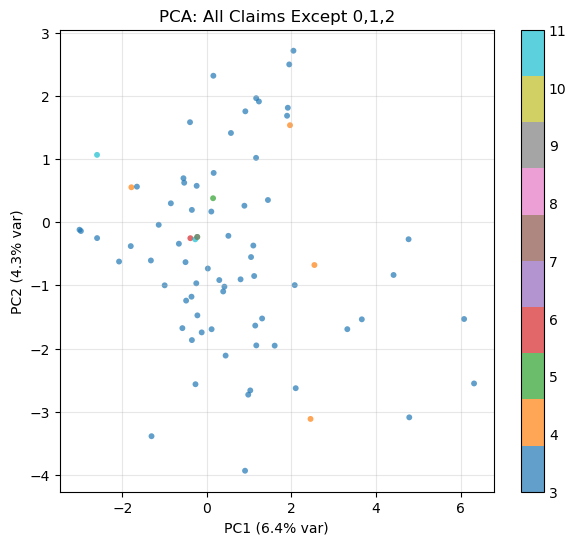

In [95]:
y_np = Y.to_numpy()
mask_np = ~np.isin(y_np, [0,1,2])

X_pca_filtered = X_all[mask_np]
Y_filtered     = y_np[mask_np]

plt.figure(figsize=(7,6))
sc = plt.scatter(
    X_pca_filtered[:, 0],
    X_pca_filtered[:, 1],
    c=Y_filtered, cmap='tab10',
    s=18, alpha=0.7, edgecolor='none'
)
cbar = plt.colorbar(sc)
cbar.ax.tick_params(width=0, length=0)
plt.xlabel(f"PC1 ({pca_all.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca_all.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA: All Claims Except 0,1,2")
plt.grid(alpha=0.3)
plt.show()

